In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score # métrica de evaluación
from sklearn.metrics import classification_report
from sklearn import metrics
import sweetviz as sv

# Análisis Exploratorio

In [74]:
df_nasa = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/asteroids_nasa.csv')
df_nasa.head(5)
import sweetviz as sv
reporte = sv.analyze(df_nasa, target_feat="Hazardous")
reporte.show_html("reporte.html")  # abre en el browser automáticamente


                                             |          | [  0%]   00:00 -> (? left)

Report reporte.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [75]:
# verificamos los tipos de datos
df_nasa.dtypes

Neo Reference ID                  int64
Name                              int64
Absolute Magnitude              float64
Est Dia in KM(min)              float64
Est Dia in KM(max)              float64
Est Dia in M(min)               float64
Est Dia in M(max)               float64
Est Dia in Miles(min)           float64
Est Dia in Miles(max)           float64
Est Dia in Feet(min)            float64
Est Dia in Feet(max)            float64
Close Approach Date                 str
Epoch Date Close Approach         int64
Relative Velocity km per sec    float64
Relative Velocity km per hr     float64
Miles per hour                  float64
Miss Dist.(Astronomical)        float64
Miss Dist.(lunar)               float64
Miss Dist.(kilometers)          float64
Miss Dist.(miles)               float64
Orbiting Body                       str
Orbit ID                          int64
Orbit Determination Date            str
Orbit Uncertainity                int64
Minimum Orbit Intersection      float64


In [26]:
print("Tamaño del dataframe : {}".format(df_nasa.shape))

Tamaño del dataframe : (4687, 40)


In [27]:
# Verificamos si hay valores nulos para imputar
df_nasa.isnull().sum()

Neo Reference ID                0
Name                            0
Absolute Magnitude              0
Est Dia in KM(min)              0
Est Dia in KM(max)              0
Est Dia in M(min)               0
Est Dia in M(max)               0
Est Dia in Miles(min)           0
Est Dia in Miles(max)           0
Est Dia in Feet(min)            0
Est Dia in Feet(max)            0
Close Approach Date             0
Epoch Date Close Approach       0
Relative Velocity km per sec    0
Relative Velocity km per hr     0
Miles per hour                  0
Miss Dist.(Astronomical)        0
Miss Dist.(lunar)               0
Miss Dist.(kilometers)          0
Miss Dist.(miles)               0
Orbiting Body                   0
Orbit ID                        0
Orbit Determination Date        0
Orbit Uncertainity              0
Minimum Orbit Intersection      0
Jupiter Tisserand Invariant     0
Epoch Osculation                0
Eccentricity                    0
Semi Major Axis                 0
Inclination   

Hazardous
False    3932
True      755
Name: count, dtype: int64


<Axes: xlabel='Hazardous', ylabel='count'>

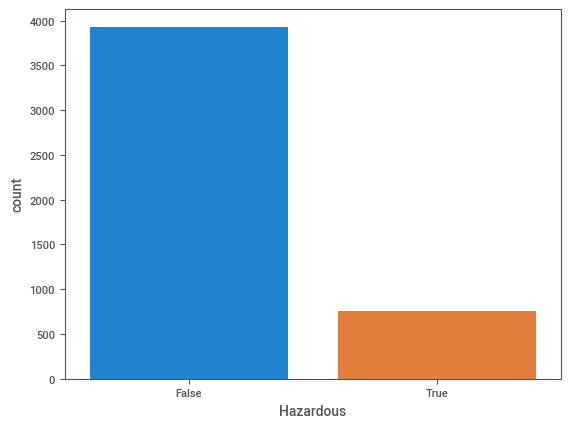

In [28]:
# Analisis de la distribución de la variable target "Hazardous"
print( df_nasa.Hazardous.value_counts() )
sns.countplot(x='Hazardous', data=df_nasa, hue='Hazardous', legend=False)

# Correlación de Variables

<Axes: >

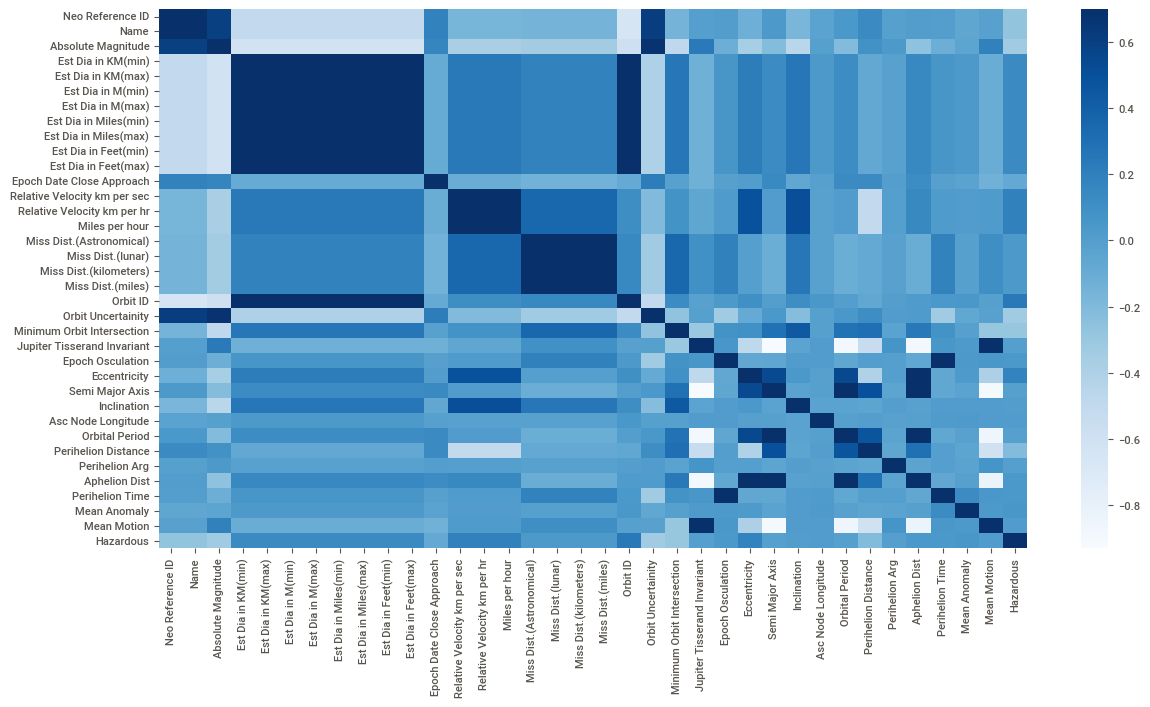

In [10]:
plt.figure(figsize=(14,7))
sns.heatmap(df_nasa.drop(['Close Approach Date','Orbiting Body','Orbit Determination Date','Equinox'],axis=1).corr(), vmax=.7, cmap ='Blues', fmt=".2f")

In [29]:
df_nasa_corr = df_nasa.drop(['Close Approach Date','Orbiting Body','Orbit Determination Date','Equinox'],axis=1).corr()[["Hazardous"]]*100 # lo pasamos a porcentajes
df_nasa_corr = df_nasa_corr.drop("Hazardous", axis=0) # eliminamos la variable target
df_nasa_corr = abs(df_nasa_corr) # nos interesa el valor absouluto
df_nasa_corr = df_nasa_corr.sort_values(["Hazardous"], ascending=False) # ordenamos en forma descendente
df_nasa_corr

,Hazardous
Orbit Uncertainity,32.872134
Absolute Magnitude,32.552193
Minimum Orbit Intersection,28.894902
Neo Reference ID,26.902814
Name,26.902814
Orbit ID,24.736904
Perihelion Distance,20.702693
Relative Velocity km per sec,19.197018
Miles per hour,19.197018
Relative Velocity km per hr,19.197018


# Seleccionamos las variables que vamos a utilizar y hacemos el Split

In [30]:
# dropeo ['Orbiting Body','Equinox'] porque en todos los casos es earth y J2000
df_nasa.drop(['Orbiting Body','Equinox'],axis=1, inplace=True)

In [31]:
df_nasa.columns

Index(['Neo Reference ID', 'Name', 'Absolute Magnitude', 'Est Dia in KM(min)',
       'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)',
       'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
       'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Close Approach Date',
       'Epoch Date Close Approach', 'Relative Velocity km per sec',
       'Relative Velocity km per hr', 'Miles per hour',
       'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)',
       'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbit ID',
       'Orbit Determination Date', 'Orbit Uncertainity',
       'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant',
       'Epoch Osculation', 'Eccentricity', 'Semi Major Axis', 'Inclination',
       'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance',
       'Perihelion Arg', 'Aphelion Dist', 'Perihelion Time', 'Mean Anomaly',
       'Mean Motion', 'Hazardous'],
      dtype='str')

In [32]:
df = df_nasa.drop(['Close Approach Date','Orbit Determination Date'],axis=1)
X_nasa = df.drop("Hazardous",axis=1)
y_nasa = df["Hazardous"]
X_nasa.head()

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Semi Major Axis,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,1.407011,6.025981,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,1.107776,28.412996,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,1.458824,4.237961,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,1.255903,7.905894,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,1.225615,16.793382,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395


In [59]:
# Hacemos el Split 70-30 para train-test
X_train, X_test, y_train, y_test = train_test_split(X_nasa, y_nasa, test_size=0.3, stratify = y_nasa, random_state=4)

In [67]:
# Creamos y entrenamos modelo
treeclf = DecisionTreeClassifier(max_depth=3, random_state=14) # maxima profundidad = 3
treeclf.fit(X_train, y_train) # entrenamos el árbol

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",14
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

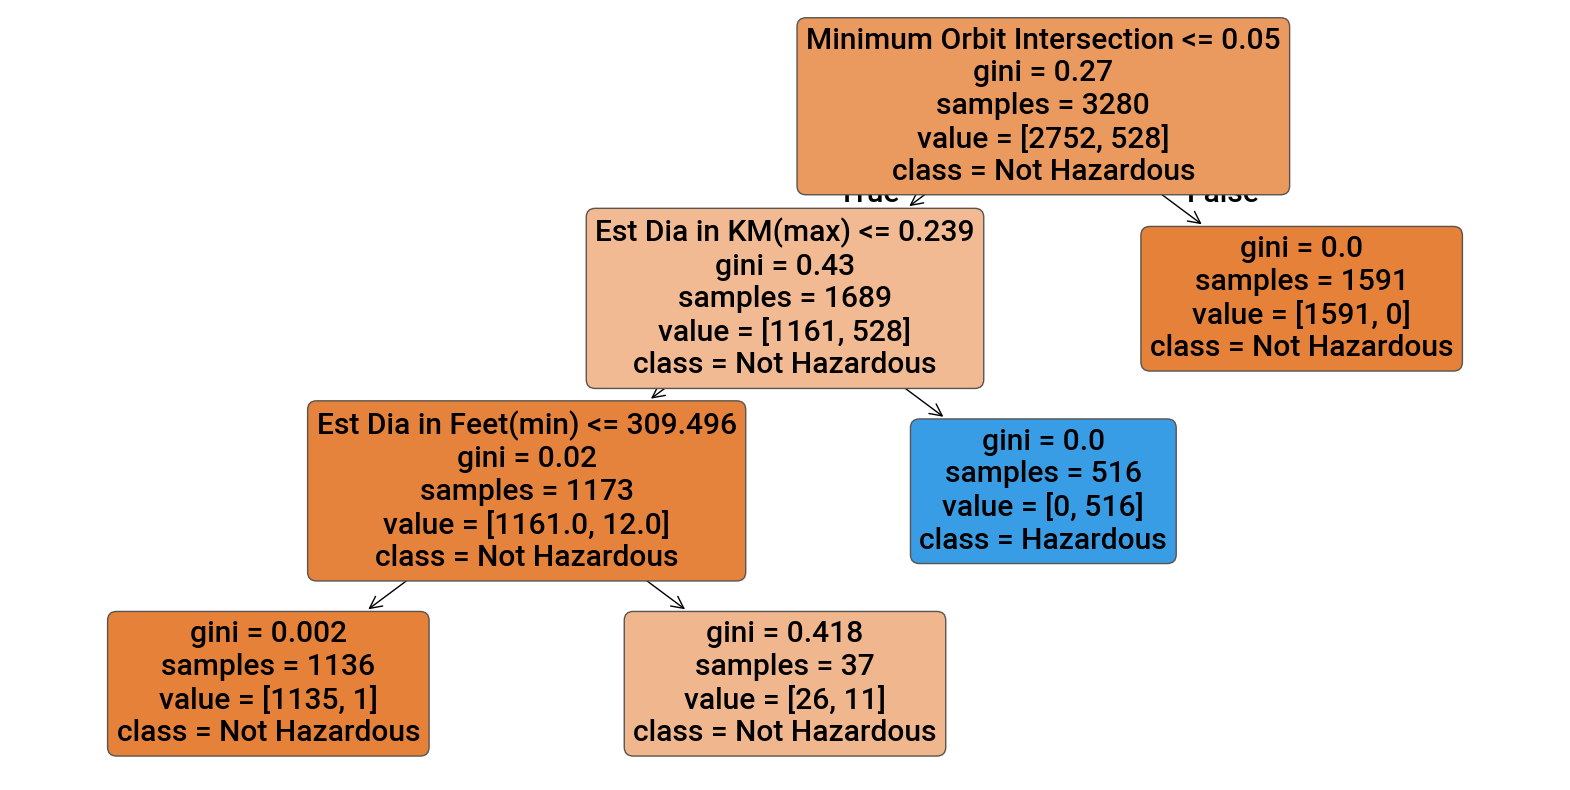

In [68]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(treeclf,
          feature_names=X_nasa.columns,
          class_names=['Not Hazardous', 'Hazardous'],
          filled=True, rounded=True)
plt.show()

In [69]:
y_pred_tc = treeclf.predict(X_test)

#Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_tc)*100))
print("-"*100)

# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_tc))

Exactitud (accuracy) del modelo: 99.22 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       False       0.99      1.00      1.00      1180
        True       1.00      0.96      0.98       227

    accuracy                           0.99      1407
   macro avg       0.99      0.98      0.99      1407
weighted avg       0.99      0.99      0.99      1407



# Comparamos por curva ROC con naive bayes

In [53]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB

bayes_multi = MultinomialNB()
bayes_multi.fit(X_train, y_train)
y_pred_nb = bayes_multi.predict(X_test)

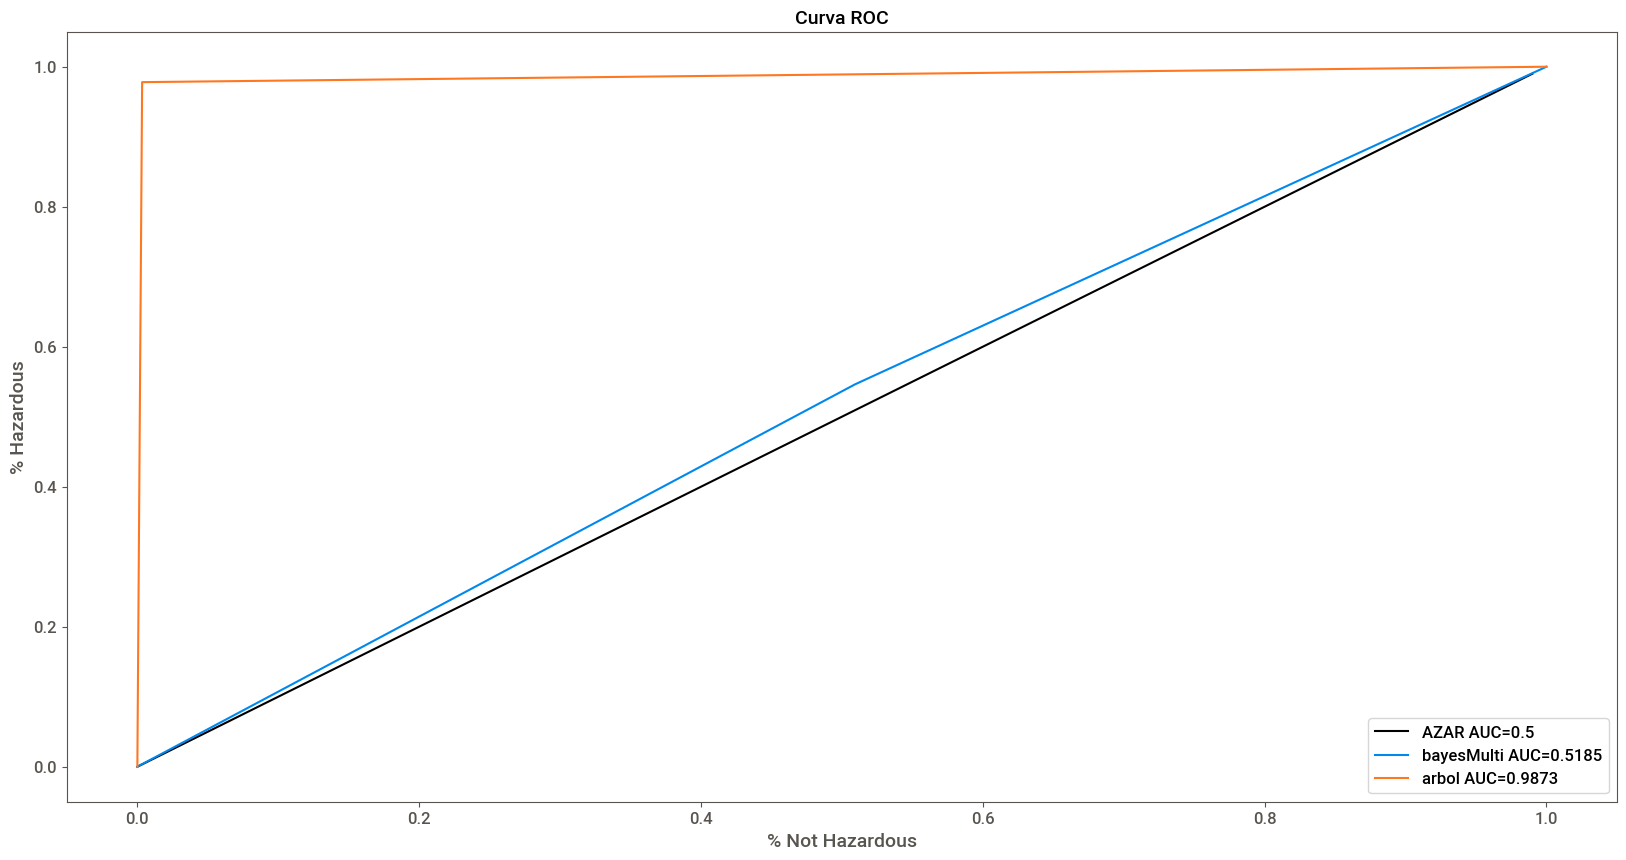

In [54]:
def graficarCurvaRoc( y_pred, model ):
  fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
  auc = metrics.roc_auc_score(y_test, y_pred)
  # Graficamos
  plt.plot(fpr,tpr,label= model +" AUC="+str(round(auc,4))) #,label= "AUC="+str(auc))
  plt.legend(loc=4, fontsize=12)
  return auc

# Inicializamos los labels del gráfico
plt.figure(figsize=(20, 10))
plt.xlabel('% Not Hazardous', fontsize=14)
plt.ylabel('% Hazardous', fontsize=14)

# Graficamos la recta del azar
it = [i/100 for i in range(100)]
plt.plot(it,it,label="AZAR AUC=0.5",color="black")

modelos = {'bayesMulti':y_pred_nb, 'arbol':y_pred_tc }
for pred in modelos:
    auc = graficarCurvaRoc( modelos[pred] , pred )

# Agregamos el titulo y configuro el tamaño de letra
plt.title("Curva ROC", fontsize=14)
plt.tick_params(labelsize=12)
plt.show()

# Ejercicio
- ¿Cómo se compara el performance del arbol con Naive bayes en este dataset?
- usando treeclf.feature_importances_ podemos ver la importancia de cada una de las columnas de X para el modelo, ¿que sucede con los arboles con menor profundidad?
- implementar un modelo de bosque aleatoreo ([random forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)) y comparar su curva ROC
- ¿Cual es la diferencia entre los hiperparametros min_samples_split y min_samples_leaf?
- ¿Como se compara la performance de un arbol de profundidad 1, 3 o 10?
- ¿Afectará al modelo si escalamos las variables?

ÁRBOL DE DECISIÓN (max_depth=3)
Accuracy: 99.22%
              precision    recall  f1-score   support

       False       0.99      1.00      1.00      1180
        True       1.00      0.96      0.98       227

    accuracy                           0.99      1407
   macro avg       0.99      0.98      0.99      1407
weighted avg       0.99      0.99      0.99      1407

NAIVE BAYES (Multinomial)
Accuracy: 48.40%
              precision    recall  f1-score   support

       False       0.83      0.48      0.61      1180
        True       0.16      0.50      0.24       227

    accuracy                           0.48      1407
   macro avg       0.49      0.49      0.42      1407
weighted avg       0.72      0.48      0.55      1407



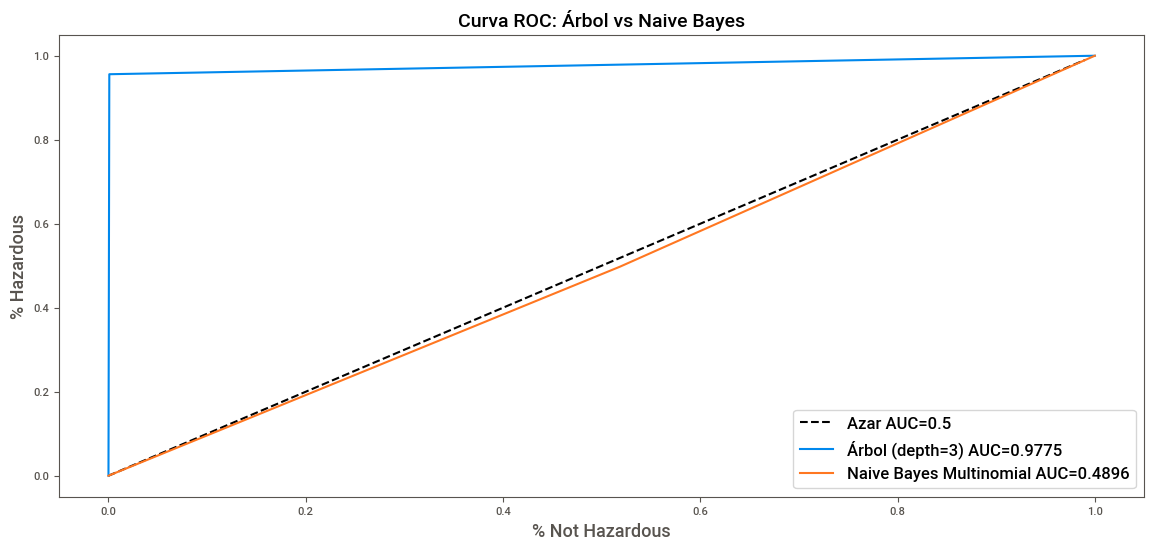

In [ ]:
# 1 naives es peor
print("=" * 50)
print("ÁRBOL DE DECISIÓN (max_depth=3)")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_tc)*100:.2f}%")
print(classification_report(y_test, y_pred_tc))

print("=" * 50)
print("NAIVE BAYES (Multinomial)")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb)*100:.2f}%")
print(classification_report(y_test, y_pred_nb))

# Comparación visual de AUC
plt.figure(figsize=(14, 6))
plt.xlabel('% Not Hazardous', fontsize=13)
plt.ylabel('% Hazardous', fontsize=13)
plt.title("Curva ROC: Árbol vs Naive Bayes", fontsize=14)

it = [i/100 for i in range(100)]
plt.plot(it, it, label="Azar AUC=0.5", color="black", linestyle="--")

graficarCurvaRoc(y_pred_tc, "Árbol (depth=3)")
graficarCurvaRoc(y_pred_nb, "Naive Bayes Multinomial")

plt.legend(fontsize=12)
plt.show()

# El árbol de decisión suele superar a Naive Bayes en este dataset porque:
# - NB asume independencia entre features (falso aquí, hay alta correlación)
# - El árbol captura interacciones entre variables sin ese supuesto




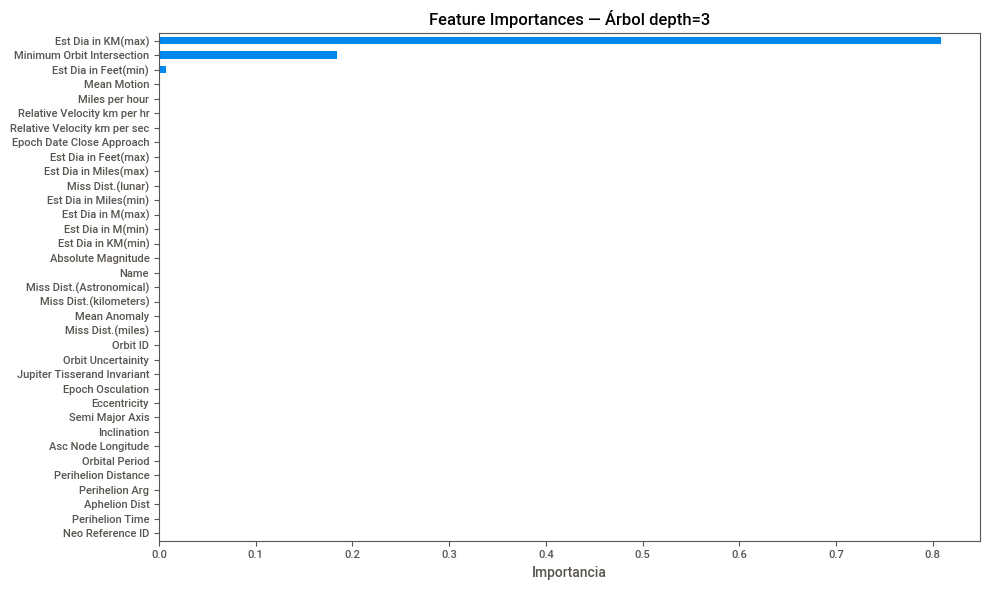

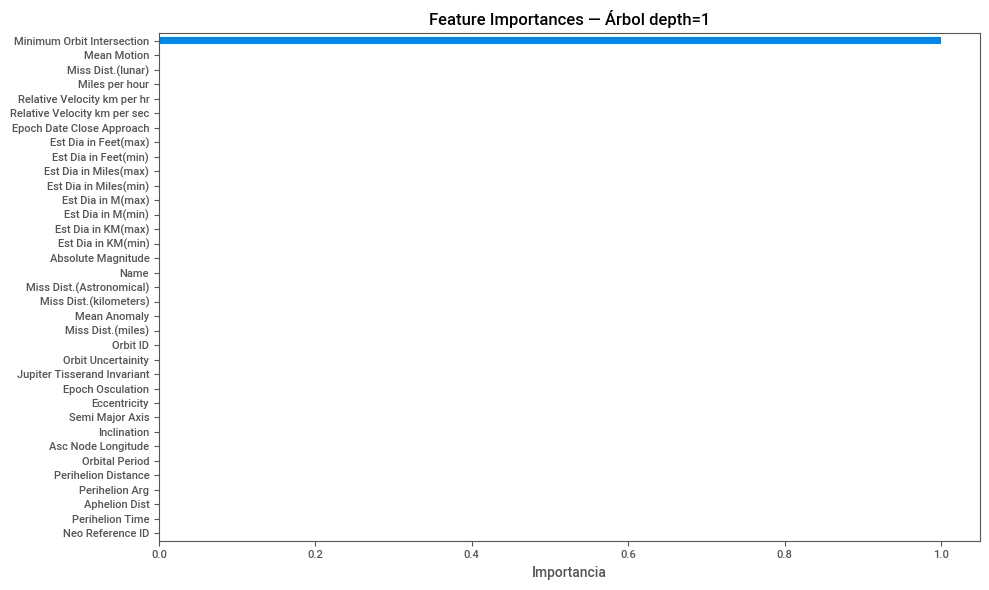

Features con importancia > 0 en depth=1: 1
Features con importancia > 0 en depth=3: 3


In [71]:
def graficar_importancias(tree, titulo):
    importancias = pd.Series(tree.feature_importances_, index=X_nasa.columns)
    importancias = importancias.sort_values(ascending=True)
    ax = importancias.plot(kind='barh', figsize=(10, 6), title=titulo)
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()

# Árbol con depth=3 (el original)
graficar_importancias(treeclf, "Feature Importances — Árbol depth=3")

# Árbol con depth=1 (solo usa la feature más discriminativa)
tree_d1 = DecisionTreeClassifier(max_depth=1, random_state=1)
tree_d1.fit(X_train, y_train)
graficar_importancias(tree_d1, "Feature Importances — Árbol depth=1")

# Con menor profundidad el árbol solo puede hacer 1 split → solo 1 feature
# tiene importancia > 0. A mayor depth, más features pueden contribuir.
print("Features con importancia > 0 en depth=1:", (tree_d1.feature_importances_ > 0).sum())
print("Features con importancia > 0 en depth=3:", (treeclf.feature_importances_ > 0).sum())

RANDOM FOREST
Accuracy: 99.43%
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      1180
        True       0.98      0.98      0.98       227

    accuracy                           0.99      1407
   macro avg       0.99      0.99      0.99      1407
weighted avg       0.99      0.99      0.99      1407



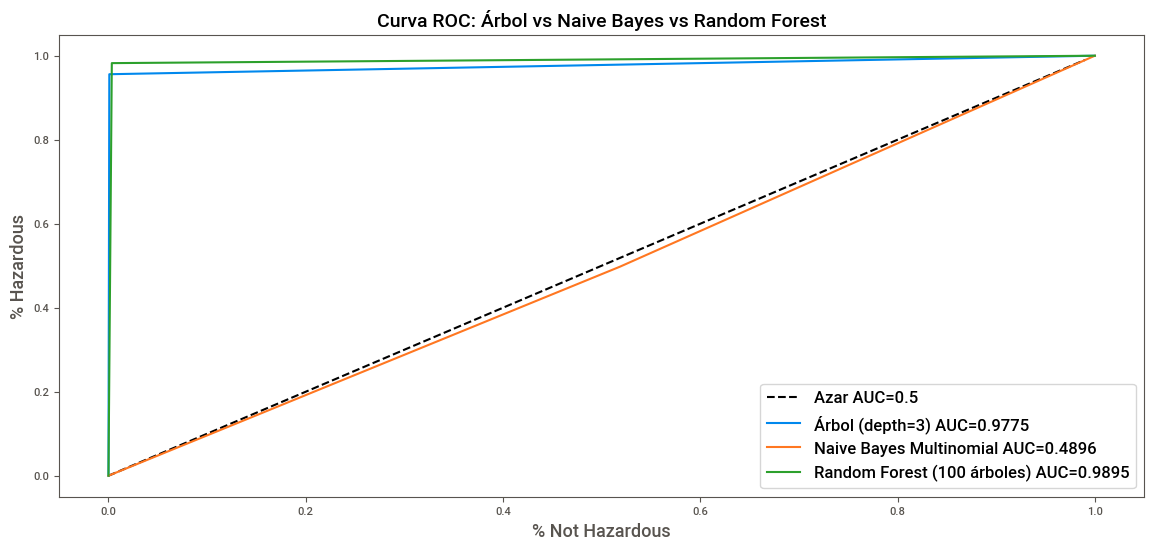

In [72]:
## 3. Random Forest — Comparación de curva ROC
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RANDOM FOREST")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(classification_report(y_test, y_pred_rf))

# Curva ROC comparando los tres modelos
plt.figure(figsize=(14, 6))
plt.xlabel('% Not Hazardous', fontsize=13)
plt.ylabel('% Hazardous', fontsize=13)
plt.title("Curva ROC: Árbol vs Naive Bayes vs Random Forest", fontsize=14)

it = [i/100 for i in range(100)]
plt.plot(it, it, label="Azar AUC=0.5", color="black", linestyle="--")

graficarCurvaRoc(y_pred_tc, "Árbol (depth=3)")
graficarCurvaRoc(y_pred_nb, "Naive Bayes Multinomial")
graficarCurvaRoc(y_pred_rf, "Random Forest (100 árboles)")

plt.legend(fontsize=12)
plt.show()

In [73]:
# Demostración: efecto de cada hiperparámetro sobre el número de nodos y accuracy
configs = [
    {"label": "default",              "min_samples_split": 2,   "min_samples_leaf": 1},
    {"label": "split=50",             "min_samples_split": 50,  "min_samples_leaf": 1},
    {"label": "leaf=25",              "min_samples_split": 2,   "min_samples_leaf": 25},
    {"label": "split=50 + leaf=25",   "min_samples_split": 50,  "min_samples_leaf": 25},
]

print(f"{'Config':<25} {'Nodos':>7} {'Hojas':>7} {'Accuracy':>10}")
print("-" * 55)
for c in configs:
    t = DecisionTreeClassifier(
        min_samples_split=c["min_samples_split"],
        min_samples_leaf=c["min_samples_leaf"],
        random_state=1
    )
    t.fit(X_train, y_train)
    acc = accuracy_score(y_test, t.predict(X_test))
    print(f"{c['label']:<25} {t.tree_.node_count:>7} {t.tree_.n_leaves:>7} {acc*100:>9.2f}%")

# min_samples_leaf=25 poda más agresivamente que min_samples_split=50
# porque controla el tamaño de AMBAS hojas resultantes de cada split.

Config                      Nodos   Hojas   Accuracy
-------------------------------------------------------
default                        21      11     99.43%
split=50                        9       5     99.22%
leaf=25                         9       5     99.22%
split=50 + leaf=25              9       5     99.22%
